<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/basket_analysis_groceries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from IPython.display import Markdown, display
import tracemalloc

import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("/content/Groceries_dataset.csv")

In [3]:
df

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [5]:
df.shape

(38765, 3)

In [6]:
df['Member_number'].unique().shape

(3898,)

In [7]:
df['itemDescription'].describe()

,itemDescription
count,38765
unique,167
top,whole milk
freq,2502


In [8]:
df['itemDescription'].value_counts()

,count
itemDescription,
whole milk,2502
other vegetables,1898
rolls/buns,1716
soda,1514
yogurt,1334
...,...
rubbing alcohol,5
bags,4
baby cosmetics,3


In [9]:
df['itemDescription'].value_counts().describe()



,count
count,167.000000
mean,232.125749
std,363.442098
min,1.000000
25%,30.500000
50%,85.000000
75%,264.000000
max,2502.000000


In [10]:
df.drop(columns=['Date'],inplace=True)

In [11]:
df = df.groupby('Member_number')['itemDescription'].apply(list).reset_index(name='Basket')

In [12]:
df

,Member_number,Basket
0,1000,"[soda, canned beer, sausage, sausage, whole mi..."
1,1001,"[frankfurter, frankfurter, beef, sausage, whol..."
2,1002,"[tropical fruit, butter milk, butter, frozen v..."
3,1003,"[sausage, root vegetables, rolls/buns, deterge..."
4,1004,"[other vegetables, pip fruit, root vegetables,..."
...,...,...
3893,4996,"[dessert, salty snack, rolls/buns, misc. bever..."
3894,4997,"[tropical fruit, white wine, whole milk, curd,..."
3895,4998,"[rolls/buns, curd]"
3896,4999,"[bottled water, butter milk, tropical fruit, b..."


In [15]:
transactions=df['Basket'].tolist()

In [20]:
# One-hot encode the transactions
te = TransactionEncoder()

# fit the encoder on your data
te_ary = te.fit(transactions).transform(transactions)

# Convert the one-hot array to a DataFrame
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

df_encoded = pd.DataFrame(te_ary, columns=te.columns_)


In [22]:
df_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


Apriori algorithm

In [27]:
n = df_encoded.shape[0]
item_counts = df_encoded.sum(axis=0)

max_freq = item_counts.max()
most_frequent_item = item_counts.idxmax()
mean_freq = item_counts.mean()
median_freq = item_counts.median()
print(f"Most frequent item: {most_frequent_item}")
print(f"max support: {max_freq / n : .2f}")

print(f"Mean support of items: {mean_freq / n : .2f}")
print(f"Median support of items: {median_freq / n : .2f}")

Most frequent item: whole milk
max support:  0.46
Mean support of items:  0.05
Median support of items:  0.02


In [28]:
tracemalloc.start()
start = time.perf_counter()

frequent_itemsets = apriori(df_encoded, min_support=0.03, use_colnames=True)

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

ap_time = end - start
ap_memory = peak / (1024 * 1024)

print(f"Apriori time: {ap_time:.6f} s")
print(f"Apriori peak RAM: {ap_memory:.2f} MB")
ap_freq_itemsets = frequent_itemsets.shape[0]


Apriori time: 0.148876 s
Apriori peak RAM: 41.33 MB


In [29]:
frequent_itemsets.sort_values(by= "support", ascending=False)


,support,itemsets
70,0.458184,(whole milk)
44,0.376603,(other vegetables)
53,0.349666,(rolls/buns)
60,0.313494,(soda)
71,0.282966,(yogurt)
...,...,...
239,0.030015,"(shopping bags, newspapers)"
180,0.030015,"(curd, root vegetables)"
176,0.030015,"(cream cheese , soda)"
116,0.030015,"(canned beer, brown bread)"


In [30]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

In [31]:
rules.shape


(94, 14)

In [32]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.55)
rules.shape

(45, 14)

In [33]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.58)
rules.shape

(19, 14)

In [34]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
rules.shape


(8, 14)

In [35]:
rules_filtered = rules[rules['lift'] >= 1.2]

rules_filtered

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(other vegetables, beef)",(whole milk),0.050795,0.458184,0.030528,0.601010,1.311723,1.0,0.007255,1.357970,0.250361,0.063807,0.263607,0.333820
1,"(bottled beer, rolls/buns)",(whole milk),0.063109,0.458184,0.038225,0.605691,1.321939,1.0,0.009309,1.374091,0.259940,0.079129,0.272246,0.344559
2,"(yogurt, bottled water)",(whole milk),0.066444,0.458184,0.040277,0.606178,1.323001,1.0,0.009833,1.375788,0.261519,0.083157,0.273144,0.347042
3,"(yogurt, pastry)",(whole milk),0.057978,0.458184,0.034890,0.601770,1.313381,1.0,0.008325,1.360561,0.253292,0.072495,0.265009,0.338959
4,"(shopping bags, rolls/buns)",(whole milk),0.068753,0.458184,0.041303,0.600746,1.311147,1.0,0.009802,1.357073,0.254829,0.085050,0.263120,0.345446
5,"(shopping bags, yogurt)",(whole milk),0.054900,0.458184,0.033094,0.602804,1.315638,1.0,0.007940,1.364102,0.253849,0.068947,0.266917,0.337516
6,"(other vegetables, rolls/buns, soda)",(whole milk),0.052591,0.458184,0.031811,0.604878,1.320165,1.0,0.007715,1.371264,0.255981,0.066417,0.270746,0.337153
7,"(other vegetables, yogurt, rolls/buns)",(whole milk),0.052335,0.458184,0.034377,0.656863,1.433623,1.0,0.010398,1.579008,0.319170,0.072198,0.366691,0.365945


In [37]:
ap_rules = rules_filtered.shape[0]
rules_filtered.shape

(8, 14)

In [38]:
rules_sorted = rules_filtered.sort_values(['confidence', 'lift'], ascending =[False, False])
rules_sorted

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
7,"(other vegetables, yogurt, rolls/buns)",(whole milk),0.052335,0.458184,0.034377,0.656863,1.433623,1.0,0.010398,1.579008,0.319170,0.072198,0.366691,0.365945
2,"(yogurt, bottled water)",(whole milk),0.066444,0.458184,0.040277,0.606178,1.323001,1.0,0.009833,1.375788,0.261519,0.083157,0.273144,0.347042
1,"(bottled beer, rolls/buns)",(whole milk),0.063109,0.458184,0.038225,0.605691,1.321939,1.0,0.009309,1.374091,0.259940,0.079129,0.272246,0.344559
6,"(other vegetables, rolls/buns, soda)",(whole milk),0.052591,0.458184,0.031811,0.604878,1.320165,1.0,0.007715,1.371264,0.255981,0.066417,0.270746,0.337153
5,"(shopping bags, yogurt)",(whole milk),0.054900,0.458184,0.033094,0.602804,1.315638,1.0,0.007940,1.364102,0.253849,0.068947,0.266917,0.337516
3,"(yogurt, pastry)",(whole milk),0.057978,0.458184,0.034890,0.601770,1.313381,1.0,0.008325,1.360561,0.253292,0.072495,0.265009,0.338959
0,"(other vegetables, beef)",(whole milk),0.050795,0.458184,0.030528,0.601010,1.311723,1.0,0.007255,1.357970,0.250361,0.063807,0.263607,0.333820
4,"(shopping bags, rolls/buns)",(whole milk),0.068753,0.458184,0.041303,0.600746,1.311147,1.0,0.009802,1.357073,0.254829,0.085050,0.263120,0.345446


In [39]:
denom = rules_sorted['antecedent support'] + rules_sorted['consequent support'] - rules_sorted['support']
ir = (rules_sorted['antecedent support'] / denom) - (rules_sorted['consequent support'] / denom)

rules_sorted['IR'] = np.abs(ir)

rules_sorted[['antecedents', 'consequents', 'support', 'confidence','lift', 'jaccard', 'kulczynski', 'IR']]

,antecedents,consequents,support,confidence,lift,jaccard,kulczynski,IR
7,"(other vegetables, yogurt, rolls/buns)",(whole milk),0.034377,0.656863,1.433623,0.072198,0.365945,0.852371
2,"(yogurt, bottled water)",(whole milk),0.040277,0.606178,1.323001,0.083157,0.347042,0.808792
1,"(bottled beer, rolls/buns)",(whole milk),0.038225,0.605691,1.321939,0.079129,0.344559,0.817844
6,"(other vegetables, rolls/buns, soda)",(whole milk),0.031811,0.604878,1.320165,0.066417,0.337153,0.846813
5,"(shopping bags, yogurt)",(whole milk),0.033094,0.602804,1.315638,0.068947,0.337516,0.840192
3,"(yogurt, pastry)",(whole milk),0.034890,0.601770,1.313381,0.072495,0.338959,0.831557
0,"(other vegetables, beef)",(whole milk),0.030528,0.601010,1.311723,0.063807,0.333820,0.851475
4,"(shopping bags, rolls/buns)",(whole milk),0.041303,0.600746,1.311147,0.085050,0.345446,0.801902


fp growth

In [40]:
tracemalloc.start()
start = time.perf_counter()

freq_itemsets = fpgrowth(df_encoded, min_support=0.03, use_colnames=True)

end = time.perf_counter()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

fp_time = end - start
fp_memory = peak / (1024 * 1024)

print(f"FP-Growth time: {fp_time:.6f} s")
print(f"FP-Growth peak RAM: {fp_memory:.2f} MB")
fp_freq_itemsets = freq_itemsets.shape[0]
freq_itemsets

FP-Growth time: 51.948606 s
FP-Growth peak RAM: 12.54 MB


,support,itemsets
0,0.458184,(whole milk)
1,0.313494,(soda)
2,0.282966,(yogurt)
3,0.206003,(sausage)
4,0.177527,(pastry)
...,...,...
410,0.034120,"(pork, root vegetables)"
411,0.030015,"(other vegetables, whole milk, pork)"
412,0.030272,"(whole milk, ice cream)"
413,0.037968,"(whole milk, waffles)"


In [41]:
rules = association_rules(freq_itemsets, metric="confidence", min_threshold=0.6)
rules.shape

(8, 14)

In [42]:
rules_filtered = rules[rules['lift'] >= 1.2]
fp_rules = rules_filtered.shape[0]
rules_filtered

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(other vegetables, rolls/buns, soda)",(whole milk),0.052591,0.458184,0.031811,0.604878,1.320165,1.0,0.007715,1.371264,0.255981,0.066417,0.270746,0.337153
1,"(other vegetables, yogurt, rolls/buns)",(whole milk),0.052335,0.458184,0.034377,0.656863,1.433623,1.0,0.010398,1.579008,0.319170,0.072198,0.366691,0.365945
2,"(yogurt, pastry)",(whole milk),0.057978,0.458184,0.034890,0.601770,1.313381,1.0,0.008325,1.360561,0.253292,0.072495,0.265009,0.338959
3,"(other vegetables, beef)",(whole milk),0.050795,0.458184,0.030528,0.601010,1.311723,1.0,0.007255,1.357970,0.250361,0.063807,0.263607,0.333820
4,"(shopping bags, rolls/buns)",(whole milk),0.068753,0.458184,0.041303,0.600746,1.311147,1.0,0.009802,1.357073,0.254829,0.085050,0.263120,0.345446
5,"(shopping bags, yogurt)",(whole milk),0.054900,0.458184,0.033094,0.602804,1.315638,1.0,0.007940,1.364102,0.253849,0.068947,0.266917,0.337516
6,"(yogurt, bottled water)",(whole milk),0.066444,0.458184,0.040277,0.606178,1.323001,1.0,0.009833,1.375788,0.261519,0.083157,0.273144,0.347042
7,"(bottled beer, rolls/buns)",(whole milk),0.063109,0.458184,0.038225,0.605691,1.321939,1.0,0.009309,1.374091,0.259940,0.079129,0.272246,0.344559


In [43]:
rules_sorted = rules_filtered.sort_values(['confidence', 'lift'], ascending =[False, False])

denom = rules_sorted['antecedent support'] + rules_sorted['consequent support'] - rules_sorted['support']
ir = (rules_sorted['antecedent support'] / denom ) - (rules_sorted['consequent support'] / denom)

rules_sorted['IR'] = np.abs(ir)

rules_sorted[['antecedents', 'consequents', 'support', 'confidence','lift', 'jaccard', 'kulczynski', 'IR']]

,antecedents,consequents,support,confidence,lift,jaccard,kulczynski,IR
1,"(other vegetables, yogurt, rolls/buns)",(whole milk),0.034377,0.656863,1.433623,0.072198,0.365945,0.852371
6,"(yogurt, bottled water)",(whole milk),0.040277,0.606178,1.323001,0.083157,0.347042,0.808792
7,"(bottled beer, rolls/buns)",(whole milk),0.038225,0.605691,1.321939,0.079129,0.344559,0.817844
0,"(other vegetables, rolls/buns, soda)",(whole milk),0.031811,0.604878,1.320165,0.066417,0.337153,0.846813
5,"(shopping bags, yogurt)",(whole milk),0.033094,0.602804,1.315638,0.068947,0.337516,0.840192
2,"(yogurt, pastry)",(whole milk),0.034890,0.601770,1.313381,0.072495,0.338959,0.831557
3,"(other vegetables, beef)",(whole milk),0.030528,0.601010,1.311723,0.063807,0.333820,0.851475
4,"(shopping bags, rolls/buns)",(whole milk),0.041303,0.600746,1.311147,0.085050,0.345446,0.801902


AttributeError: 'NoneType' object has no attribute 'remove'

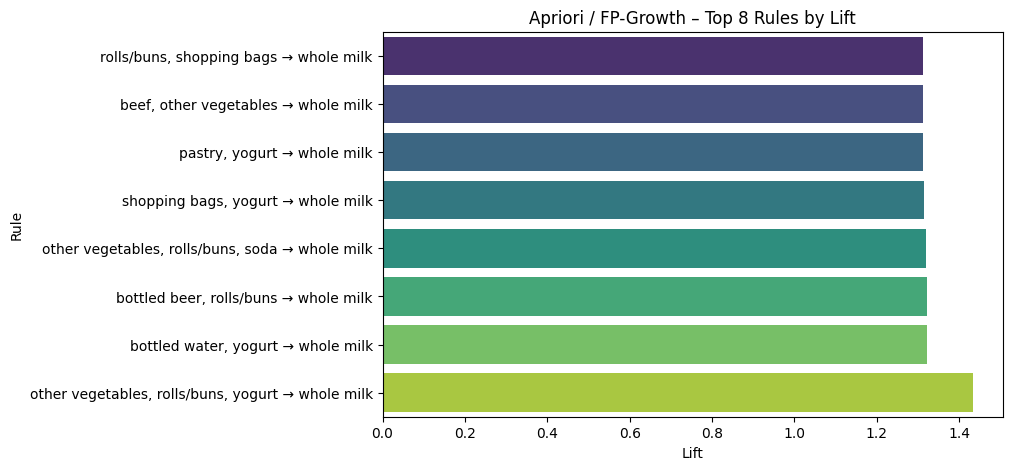

In [46]:
def rule_to_str(antecedents, consequents, max_len=70):
    a = ", ".join(sorted(list(antecedents)))
    c = ", ".join(sorted(list(consequents)))
    s = f"{a} → {c}"
    return (s[:max_len] + "…") if len(s) > max_len else s


def plot_top_rules_by_metric(rules, metric='lift', top_n=8, title_prefix=""):
    r = rules.copy()
    r['rule_str'] = r.apply(
        lambda row: rule_to_str(row['antecedents'], row['consequents']),
        axis=1
    )
    r_top = r.nlargest(top_n, metric).sort_values(metric)

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        data=r_top,
        x=metric,
        y='rule_str',
        hue='rule_str',
        dodge=False,
        palette='viridis',
        legend=False
    )

    plt.xlabel(metric.capitalize())
    plt.ylabel("Rule")
    plt.title(f"{title_prefix}Top {top_n} Rules by {metric.capitalize()}")

    ax.legend_.remove()

    plt.tight_layout()
    plt.show()


plot_top_rules_by_metric(rules_filtered, metric='lift', top_n=8,
                         title_prefix="Apriori / FP-Growth – ")